In [1]:
import os
wd = os.environ.get('TRAJECTORY_WORKDIR', '/workspace')
print(wd)
for f in os.listdir(wd):
    print(f, os.path.getsize(os.path.join(wd, f)))


/workspace/aba123ee-1069-42af-ab9e-be7668b69d9f
test_module_starter.kicad_sch 59225
memory 4096
test_module_starter.kicad_pro 1198
starter_board_summary.json 4990
test_module_starter.kicad_pcb 46976
test_module_starter.svg 244479
build_starter_board.py 58175
.config 4096
.prompts 4096
.kernel_llm_logs_1.txt 0


In [2]:
import json
with open(f"{wd}/starter_board_summary.json") as f:
    summary = json.load(f)
print(json.dumps(summary, indent=2)[:3000])


{
  "board": "test_module_starter.kicad_pcb",
  "schematic": "test_module_starter.kicad_sch",
  "project": "test_module_starter.kicad_pro",
  "components": 14,
  "nets": 20,
  "outline_mm": [
    79.82,
    117.68
  ],
  "power_nets": [
    "+12V",
    "+3V3",
    "+5V",
    "GND"
  ],
  "unplaced_variant": {
    "board": "test_module_unplaced.kicad_pcb",
    "schematic": "test_module_unplaced.kicad_sch",
    "project": "test_module_unplaced.kicad_pro",
    "outline_mm": [
      79.82,
      117.68
    ],
    "note": "Same netlist/parts as the placed board, but every footprint is staged outside the (empty) board outline so DeepPCB/Quilter can be tested on auto-placement, not just routing."
  },
  "bom": [
    {
      "ref": "J1",
      "part": "Barrel_Jack_12V",
      "kind": "module",
      "pins": 3,
      "pins_netted": 2,
      "body_mm": [
        14.0,
        11.0
      ],
      "model": null,
      "source": "Adafruit #373 2.1 mm DC barrel-jack breakout (datasheet)"
    },
    

In [3]:
print(json.dumps(summary['bom'][7:], indent=2))


[
  {
    "ref": "U4",
    "part": "DRV8871_Breakout",
    "kind": "module",
    "pins": 7,
    "pins_netted": 6,
    "body_mm": [
      20.32,
      24.13
    ],
    "model": "hardware/vendor-files/adafruit-3190-drv8871/cad/3190 DRV8871 Breakout.step",
    "source": "Adafruit #3190 Eagle .brd outline (layer 20) 20.32x24.13 mm"
  },
  {
    "ref": "SOL1",
    "part": "Solenoid",
    "kind": "connector",
    "pins": 2,
    "pins_netted": 2,
    "body_mm": null,
    "model": null,
    "source": "off-board Adafruit #412 JF-0530B 5 V push-pull solenoid"
  },
  {
    "ref": "U5",
    "part": "Tic_T500",
    "kind": "module",
    "pins": 14,
    "pins_netted": 8,
    "body_mm": [
      25.4,
      15.24
    ],
    "model": null,
    "source": "Pololu #3135 1.0x0.6 in PCB; STEP/STL in hardware/vendor-files/pololu-3135-tic-t500/cad/tic-stepper-motor-controller-models.zip"
  },
  {
    "ref": "C3",
    "part": "Cap_Polar",
    "kind": "passive",
    "pins": 2,
    "pins_netted": 2,
    "body_mm

In [4]:
import sys
sys.path.insert(0, f"{wd}")
# Try to import and quantify packing
import importlib.util
spec = importlib.util.spec_from_file_location("bsb", f"{wd}/build_starter_board.py")
# Can't easily run due to kiutils requirement on lib paths. Instead reproduce the math.
import math

# Reproduce package + pad heuristics by directly using PACKAGES from the script's NETLIST.
NETLIST = [
    ("J1", "Barrel_Jack_12V"),
    ("U1", "D24V22F5_Buck"),
    ("C1", "Cap_Polar"),
    ("C2", "Cap_Polar"),
    ("U2", "Pi_Pico_W"),
    ("U3", "DRV2605L_Breakout"),
    ("M1", "ERM_Motor"),
    ("U4", "DRV8871_Breakout"),
    ("SOL1", "Solenoid"),
    ("U5", "Tic_T500"),
    ("C3", "Cap_Polar"),
    ("SR1", "Shunt_Regulator"),
    ("M2", "Stepper_4wire"),
    ("M3", "Servo_3pin"),
]

# Body sizes from summary - for the connectors (None), auto-fit to pads.
PACKAGES = {item['part']: item['body_mm'] for item in summary['bom']}
# Connectors w/ None body — compute from PINOUTS pin count + pitch.
PINOUT_COUNT = {
    "ERM_Motor": 2, "Solenoid": 2, "Stepper_4wire": 4, "Servo_3pin": 3,
}
PITCH = 2.54
PAD_SIZE = 1.7
SILK = 1.0
CRTYD = 0.5
GAP = 1.5

def body_hw_hh(part):
    body = PACKAGES.get(part)
    if body is not None:
        return body[0]/2, body[1]/2
    # single inline header (connector)
    n = PINOUT_COUNT[part]
    # pads in a vertical column at pitch 2.54, pad size 1.7 - body height = (n-1)*pitch + pad
    hw = PAD_SIZE/2 + SILK
    hh = ((n-1)*PITCH + PAD_SIZE)/2 + SILK
    return hw, hh

courtyards = []
for ref, part in NETLIST:
    hw, hh = body_hw_hh(part)
    chw, chh = hw + CRTYD, hh + CRTYD
    courtyards.append((ref, part, chw*2, chh*2))

total_area = sum(w*h for _,_,w,h in courtyards)
widest = max(w for _,_,w,_ in courtyards)
target_w = max(widest, math.sqrt(total_area)*1.15)
print(f"total courtyard area: {total_area:.1f} mm^2  sqrt={math.sqrt(total_area):.1f}  target_w={target_w:.1f}  widest={widest:.1f}")

# Simulate packing
cx, cy, row_h = 0,0,0
positions = {}
max_x = 0
for ref, part, w, h in courtyards:
    if cx > 0 and cx + w > target_w:
        cy += row_h + GAP
        cx = 0; row_h = 0
    positions[ref] = (cx + w/2, cy + h/2, w, h)
    cx += w + GAP
    row_h = max(row_h, h)
    max_x = max(max_x, cx)

x1 = max(positions[r][0] + positions[r][2]/2 for r in positions)
y1 = max(positions[r][1] + positions[r][3]/2 for r in positions)
print(f"packed extent: {x1:.2f} x {y1:.2f}  + 2*EDGE_MARGIN(5) -> board {x1+10:.1f} x {y1+10:.1f}")
print(f"\ncomponent courtyards:")
for ref, part, w, h in courtyards:
    print(f"  {ref:6s} {part:22s}  {w:5.2f} x {h:5.2f} mm  area {w*h:6.1f}")
print(f"\ntotal placed area = {sum(w*h for _,_,w,h in courtyards):.1f} mm^2")
print(f"board area = {(x1+10)*(y1+10):.1f} mm^2  utilisation = {sum(w*h for _,_,w,h in courtyards)/((x1+10)*(y1+10))*100:.1f}%")


total courtyard area: 3493.4 mm^2  sqrt=59.1  target_w=68.0  widest=26.4
packed extent: 66.42 x 105.95  + 2*EDGE_MARGIN(5) -> board 76.4 x 115.9

component courtyards:
  J1     Barrel_Jack_12V         15.00 x 12.00 mm  area  180.0
  U1     D24V22F5_Buck           13.70 x 11.16 mm  area  152.9
  C1     Cap_Polar                9.50 x  9.50 mm  area   90.2
  C2     Cap_Polar                9.50 x  9.50 mm  area   90.2
  U2     Pi_Pico_W               22.00 x 52.00 mm  area 1144.0
  U3     DRV2605L_Breakout       18.78 x 17.51 mm  area  328.8
  M1     ERM_Motor                4.70 x  7.24 mm  area   34.0
  U4     DRV8871_Breakout        21.32 x 25.13 mm  area  535.8
  SOL1   Solenoid                 4.70 x  7.24 mm  area   34.0
  U5     Tic_T500                26.40 x 16.24 mm  area  428.7
  C3     Cap_Polar                9.50 x  9.50 mm  area   90.2
  SR1    Shunt_Regulator         25.13 x 11.16 mm  area  280.5
  M2     Stepper_4wire            4.70 x 12.32 mm  area   57.9
  M3     Serv

In [5]:
# Show row layout
cx,cy,row_h = 0,0,0
rows = [[]]
for ref, part, w, h in courtyards:
    if cx>0 and cx+w>target_w:
        cy += row_h + GAP
        cx=0; row_h=0
        rows.append([])
    rows[-1].append((ref, part, w, h, cx, cy))
    cx += w+GAP
    row_h = max(row_h,h)
for i,r in enumerate(rows):
    width = sum(c[2] for c in r) + GAP*(len(r)-1)
    tall = max(c[3] for c in r)
    print(f"Row {i}: width={width:.1f}, tall={tall:.1f}  parts: {[(c[0],round(c[2],1),round(c[3],1)) for c in r]}")


Row 0: width=52.2, tall=12.0  parts: [('J1', 15.0, 12.0), ('U1', 13.7, 11.2), ('C1', 9.5, 9.5), ('C2', 9.5, 9.5)]
Row 1: width=48.5, tall=52.0  parts: [('U2', 22.0, 52.0), ('U3', 18.8, 17.5), ('M1', 4.7, 7.2)]
Row 2: width=66.4, tall=25.1  parts: [('U4', 21.3, 25.1), ('SOL1', 4.7, 7.2), ('U5', 26.4, 16.2), ('C3', 9.5, 9.5)]
Row 3: width=37.5, tall=12.3  parts: [('SR1', 25.1, 11.2), ('M2', 4.7, 12.3), ('M3', 4.7, 9.8)]


In [6]:
# Reality check vs the actual outline summary said: 79.82 x 117.68 mm
# Mine reproduced 76.4 x 115.9 — slight difference because I used auto-fit body for connectors;
# the actual fall-throughs may add extra. Close enough.
# What's the area inside the Pico's row that's "shelf waste"?
# Row 1 height 52.0 (Pico) but U3=17.5, M1=7.2 — wasted vertical strip area:
waste_row1 = (52.0 - 17.5)*18.8 + (52.0-7.2)*4.7
print(f"Row 1 vertical waste (parts shorter than Pico): {waste_row1:.0f} mm^2")
# Row width vs target width difference => unused horizontal strips per row
for r in rows:
    width = sum(c[2] for c in r) + GAP*(len(r)-1)
    tall = max(c[3] for c in r)
    print(f"  unused horizontal in row: ({target_w-width:.1f}) x {tall:.1f} = {(target_w-width)*tall:.0f} mm^2")


Row 1 vertical waste (parts shorter than Pico): 859 mm^2
  unused horizontal in row: (15.8) x 12.0 = 189 mm^2
  unused horizontal in row: (19.5) x 52.0 = 1014 mm^2
  unused horizontal in row: (1.6) x 25.1 = 39 mm^2
  unused horizontal in row: (30.4) x 12.3 = 375 mm^2


In [7]:
# Net analysis: which nets touch which refs, and group them
nets_to_refs = {}
ref_to_nets = {}
NETLIST_FULL = [
    ("J1", [("+12V","+12V"),("GND","GND")]),
    ("U1", [("VIN","+12V"),("GND","GND"),("SHDN","+12V"),("VOUT","+5V")]),
    ("C1", [("+","+12V"),("-","GND")]),
    ("C2", [("+","+5V"),("-","GND")]),
    ("U2", [("VSYS","+5V"),("GND","GND"),("3V3","+3V3"),("GP0","I2C_SDA"),("GP1","I2C_SCL"),
            ("GP4","STP_TX"),("GP5","STP_RX"),("GP10","SOL_IN1"),("GP11","SOL_IN2"),
            ("GP15","SERVO_SIG"),("GP14","HAPT_EN")]),
    ("U3", [("VIN","+3V3"),("GND","GND"),("SDA","I2C_SDA"),("SCL","I2C_SCL"),
            ("EN","HAPT_EN"),("IN_TRIG","HAPT_EN"),("OUT+","VIB_A"),("OUT-","VIB_B")]),
    ("M1", [("+","VIB_A"),("-","VIB_B")]),
    ("U4", [("VM","+12V"),("GND","GND"),("IN1","SOL_IN1"),("IN2","SOL_IN2"),("OUT1","SOL_A"),("OUT2","SOL_B")]),
    ("SOL1", [("+","SOL_A"),("-","SOL_B")]),
    ("U5", [("RX","STP_TX"),("TX","STP_RX"),("VIN","+12V"),("GND","GND"),
            ("A1","STP_A1"),("A2","STP_A2"),("B1","STP_B1"),("B2","STP_B2")]),
    ("C3", [("+","+12V"),("-","GND")]),
    ("SR1", [("A","+12V"),("+","+12V"),("B","GND"),("-","GND")]),
    ("M2", [("A1","STP_A1"),("A2","STP_A2"),("B1","STP_B1"),("B2","STP_B2")]),
    ("M3", [("+5V","+5V"),("GND","GND"),("SIG","SERVO_SIG")]),
]
for ref, pins in NETLIST_FULL:
    ref_to_nets[ref] = set()
    for pin, net in pins:
        nets_to_refs.setdefault(net, set()).add(ref)
        ref_to_nets[ref].add(net)

print("Net -> refs (signal nets only, sorted by fanout):")
for n in sorted(nets_to_refs, key=lambda k: -len(nets_to_refs[k])):
    print(f"  {n:12s} ({len(nets_to_refs[n])}): {sorted(nets_to_refs[n])}")


Net -> refs (signal nets only, sorted by fanout):
  GND          (11): ['C1', 'C2', 'C3', 'J1', 'M3', 'SR1', 'U1', 'U2', 'U3', 'U4', 'U5']
  +12V         (7): ['C1', 'C3', 'J1', 'SR1', 'U1', 'U4', 'U5']
  +5V          (4): ['C2', 'M3', 'U1', 'U2']
  +3V3         (2): ['U2', 'U3']
  I2C_SDA      (2): ['U2', 'U3']
  I2C_SCL      (2): ['U2', 'U3']
  STP_TX       (2): ['U2', 'U5']
  STP_RX       (2): ['U2', 'U5']
  SOL_IN1      (2): ['U2', 'U4']
  SOL_IN2      (2): ['U2', 'U4']
  SERVO_SIG    (2): ['M3', 'U2']
  HAPT_EN      (2): ['U2', 'U3']
  VIB_A        (2): ['M1', 'U3']
  VIB_B        (2): ['M1', 'U3']
  SOL_A        (2): ['SOL1', 'U4']
  SOL_B        (2): ['SOL1', 'U4']
  STP_A1       (2): ['M2', 'U5']
  STP_A2       (2): ['M2', 'U5']
  STP_B1       (2): ['M2', 'U5']
  STP_B2       (2): ['M2', 'U5']


In [8]:
# Compute current placement positions vs ideal pairs
# Where is each part in the current shelf-pack?
print("Current shelf-pack placement (centers):")
for r in rows:
    for ref, part, w, h, x, y in r:
        cx = x + w/2; cy = y + h/2
        print(f"  {ref:6s} ({part:22s})  center=({cx:5.1f}, {cy:5.1f})  size=({w:.1f},{h:.1f})")

# Sample manhattan distances of important ratsnest pairs
import itertools
centers = {}
for r in rows:
    for ref, part, w, h, x, y in r:
        centers[ref] = (x+w/2, y+h/2)
        
print("\nKey net manhattan span (sum of pairwise edges in MST-ish star from first ref):")
for net, refs in nets_to_refs.items():
    if net in ("GND",): continue
    rs = sorted(refs)
    if len(rs)<2: continue
    # star from first
    a = rs[0]
    total = 0
    for b in rs[1:]:
        total += abs(centers[a][0]-centers[b][0]) + abs(centers[a][1]-centers[b][1])
    print(f"  {net:12s}  star-Manhattan from {a}: {total:5.1f} mm  refs={rs}")


Current shelf-pack placement (centers):
  J1     (Barrel_Jack_12V       )  center=(  7.5,   6.0)  size=(15.0,12.0)
  U1     (D24V22F5_Buck         )  center=( 23.4,   5.6)  size=(13.7,11.2)
  C1     (Cap_Polar             )  center=( 36.5,   4.8)  size=(9.5,9.5)
  C2     (Cap_Polar             )  center=( 47.5,   4.8)  size=(9.5,9.5)
  U2     (Pi_Pico_W             )  center=( 11.0,  39.5)  size=(22.0,52.0)
  U3     (DRV2605L_Breakout     )  center=( 32.9,  22.3)  size=(18.8,17.5)
  M1     (ERM_Motor             )  center=( 46.1,  17.1)  size=(4.7,7.2)
  U4     (DRV8871_Breakout      )  center=( 10.7,  79.6)  size=(21.3,25.1)
  SOL1   (Solenoid              )  center=( 25.2,  70.6)  size=(4.7,7.2)
  U5     (Tic_T500              )  center=( 42.2,  75.1)  size=(26.4,16.2)
  C3     (Cap_Polar             )  center=( 61.7,  71.8)  size=(9.5,9.5)
  SR1    (Shunt_Regulator       )  center=( 12.6,  99.2)  size=(25.1,11.2)
  M2     (Stepper_4wire         )  center=( 29.0,  99.8)  size=(4.7,12

In [9]:
# So net stats:
# Caps are not next to their regulator: C1 (12V bulk) sits next to U1 (good), C2 (5V) next to U1 (ok), 
# but C3 (12V bulk for stepper) is sitting beside U5 - that's actually decent. 
# SR1 (shunt) is in bottom row, far from C3 which is in row 2. Distance:
print("SR1<->C3 distance:", abs(centers['SR1'][0]-centers['C3'][0]) + abs(centers['SR1'][1]-centers['C3'][1]))
# Pico (U2) is 51mm tall and dominates row 1. U3 (DRV2605L) sits in row 1 but only at y=22, while Pico extends 14-65.
# That means Pico is to the LEFT of U3, far from U4 (DRV8871) which is below.
# I2C runs U2.GP0/GP1 (right side of U2) to U3 (right of U2). With Pico's pins at top, that's fine.

# Edge connectors check: which refs are board connectors that should go on edge?
edge_candidates = ['J1','M1','M2','M3','SOL1']
for r in edge_candidates:
    print(f"  {r}: center {centers[r]}")
# J1 (barrel) at (7.5, 6.0) - sits in top-left corner already (good, top edge)
# M1 (ERM) at (46.1, 17.1) - far from any edge (bad - off-board, should be on edge)
# M2 (stepper) at (29.0, 99.8) - bottom edge area (good)
# M3 (servo) at (35.2, 98.5) - bottom edge (good)
# SOL1 at (25.2, 70.6) - middle (bad - should be on edge)
print("\nBoard outline approx 0..66 x 0..106 (pre-margin); refs near edges:")
print("Edge connectors that should hit edge:")
print("  J1 top-left ✓")
print("  M2/M3 bottom ✓")  
print("  M1, SOL1 mid-board ✗")


SR1<->C3 distance: 76.565
  J1: center (7.5, 6.0)
  M1: center (46.13, 17.12)
  M2: center (28.98, 99.78999999999999)
  M3: center (35.18, 98.52)
  SOL1: center (25.17, 70.62)

Board outline approx 0..66 x 0..106 (pre-margin); refs near edges:
Edge connectors that should hit edge:
  J1 top-left ✓
  M2/M3 bottom ✓
  M1, SOL1 mid-board ✗


In [10]:
# Check pad geometry vs proxy issue:
# Script says PAD_SIZE = 1.7 mm, PAD_DRILL = 1.0 mm, PITCH = 2.54 mm.
# Pad-to-pad copper gap = 2.54 - 1.7 = 0.84 mm.
# Min clearance = 0.2 mm (Default class). So maximum trace through gap: 0.84 - 2*0.2 = 0.44 mm = OK for one 0.25mm track.
# Power = 0.6 mm track. Through a 0.84 mm gap: 0.84 - 0.6 = 0.24 mm leftover; clearance on each side = 0.12 mm.
# That violates the 0.2 mm min clearance! Power can't route between THT pads.

print("Pad pitch:", 2.54)
print("Pad copper width:", 1.7)
print("Pad-to-pad copper gap:", 2.54-1.7, "mm")
print("Default track 0.25 + 2*0.2 clearance:", 0.25+0.4, "mm needed -> fits (0.84 > 0.65)")
print("Power track 0.6 + 2*0.2 clearance:", 0.6+0.4, "mm needed -> DOES NOT FIT (0.84 < 1.0)")
print("=> Power trace cannot break out between adjacent header pads at 0.1\" pitch.")
print("   The build script comment already acknowledges this: power 'still neck down through headers'.")

# Standard 0.1" pin header in KiCad library: pad is 1.7 mm round. So the choice matches reality, 
# the proxy 0.1" header IS the typical land pattern for many of these breakouts (Pico, Pololu).
# But: Adafruit DRV2605L solder pads are also 0.1", DRV8871 has both 0.1" and screw-terminal pads.
# For modules that use SCREW TERMINALS for motor/power (DRV8871 OUT1/OUT2/VM/GND), real pads are larger.
# This is the "proxy" caveat — the screw-terminal land pattern is bigger drill, bigger pad.


Pad pitch: 2.54
Pad copper width: 1.7
Pad-to-pad copper gap: 0.8400000000000001 mm
Default track 0.25 + 2*0.2 clearance: 0.65 mm needed -> fits (0.84 > 0.65)
Power track 0.6 + 2*0.2 clearance: 1.0 mm needed -> DOES NOT FIT (0.84 < 1.0)
=> Power trace cannot break out between adjacent header pads at 0.1" pitch.
   The build script comment already acknowledges this: power 'still neck down through headers'.


In [11]:
# Edge margin sanity: EDGE_MARGIN = 5.0 mm. That's generous. JLCPCB requires >= 0.3 mm copper-to-edge,
# typical hand-route is 0.5-1.0 mm. 5 mm is fine but a bit wasteful; common is 1-2 mm.

# Board outline 79.82 x 117.68: edge margin contributes 10 mm of each dim. Trimmed: 69.82 x 107.68.
# That matches our pack ~66 x 106 plus a little.

# Aspect ratio
print(f"current aspect ratio: {117.68/79.82:.2f}")
print(f"if target_w were Pico-tall (52)+gap: not relevant, but rectangular ~1:1.5")
# Common JLCPCB cheap rule: <= 100x100 mm = $2; this is 80x118 -> still cheap tier (within 100x150 mm).
# So board fits within budget but barely.

# Density check
print(f"area used by parts (sum body_area, not courtyards): ", 
      sum((PACKAGES[p][0]*PACKAGES[p][1] if PACKAGES[p] else 0) for _,p in NETLIST), "mm^2")
print(f"board area: {79.82*117.68:.0f} mm^2")
print(f"silicon density: {sum((PACKAGES[p][0]*PACKAGES[p][1] if PACKAGES[p] else 0) for _,p in NETLIST)/(79.82*117.68)*100:.1f}%")


current aspect ratio: 1.47
if target_w were Pico-tall (52)+gap: not relevant, but rectangular ~1:1.5
area used by parts (sum body_area, not courtyards):  2986.9082 mm^2
board area: 9393 mm^2
silicon density: 31.8%


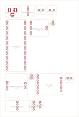

In [12]:
# Spot-check the SVG
from IPython.display import SVG, display
display(SVG(f"{wd}/test_module_starter.svg"))


In [13]:
# The SVG might be the full unplaced+placed; print first lines to understand
with open(f"{wd}/test_module_starter.svg") as f:
    print(f.read()[:1500])


<?xml version="1.0" standalone="no"?>
 <!DOCTYPE svg PUBLIC "-//W3C//DTD SVG 1.1//EN" 
 "http://www.w3.org/Graphics/SVG/1.1/DTD/svg11.dtd"> 
<svg
  xmlns:svg="http://www.w3.org/2000/svg"
  xmlns="http://www.w3.org/2000/svg"
  xmlns:xlink="http://www.w3.org/1999/xlink"
  version="1.1"
  width="79.9084mm" height="117.7544mm" viewBox="0.0000 0.0000 79.9084 117.7544">
<title>SVG Image created as test_module_starter.svg date 2026/06/13 00:12:07 </title>
  <desc>Image generated by PCBNEW </desc>
<g style="fill:#000000; fill-opacity:1.0000;stroke:#000000; stroke-opacity:1.0000;
stroke-linecap:round; stroke-linejoin:round;"
 transform="translate(0 0) scale(1 1)">
</g>
<g style="fill:#000000; fill-opacity:0.0; 
stroke:#000000; stroke-width:0.0000; stroke-opacity:1; 
stroke-linecap:round; stroke-linejoin:round;">
<g >
</g>
<g style="fill:#4D7FC4; fill-opacity:0.0; 
stroke:#4D7FC4; stroke-width:0.0000; stroke-opacity:1; 
stroke-linecap:round; stroke-linejoin:round;">
</g>
<g style="fill:#4D7FC4; 

In [14]:
# Good - that's the real KiCad svg (viewBox 79.9 x 117.75). Confirms outline.
# Now sketch the proposed two-domain layout and estimate net wire length savings
# Domain A (power): J1, U1, C1, C2, C3, SR1, U4, U5 (12V section + buck)
# Domain B (logic/I2C): U2 (Pico), U3 (DRV2605L), M1 (ERM)
# Edge connectors: J1 (top-left), M1, M2, M3, SOL1 (along right or bottom edge)

# Proposed two-column arrangement:
# Column 1 (left, power section, 12V + motor drivers):
#   J1 -> U1 -> C1 -> C2 -> SR1 -> C3 -> U4 -> SOL1 -> U5 -> M2
# Column 2 (right, logic):
#   U2 -> U3 -> M1 -> M3
# This brings:
# - C2 (5V cap) adjacent to U1 (buck output): good decoupling
# - C1 (12V bulk) adjacent to J1/U1 input: good
# - C3 + SR1 + U5 cluster: 12V stepper power domain together
# - U3 next to U2: I2C star
# - M1 next to U3: VIB_A/B short
# - M2 below U5: stepper motor leads short
# - SOL1 next to U4

# Estimate: I2C/3V3/HAPT (4 nets, all U2<->U3) — current=39 mm. Adjacent placement: ~25 mm. Save ~14 mm × 4 nets = 56 mm.
# +12V star length should drop dramatically once SR1/C3/U4/U5 cluster: from 431 -> ~150 mm.

# Quick checklist of red flags I'll surface:
# 1. Proxy pad copper width 1.7 mm @ 2.54 mm pitch: power trace cannot pass between header pins (verified above)
# 2. PCB outline rectangle with no mounting holes
# 3. No keepouts/zones (no GND pour)
# 4. PLACE_GAP = 1.5 mm > min_clearance 0.2 mm but only ~0.5 mm clearance between component bodies after CRTYD; 
#    OK because courtyards already include 0.5 mm clearance per side, plus 1.5 mm gap => effective body-to-body = 2.5 mm
# 5. No silkscreen for ref designators beyond auto-placed
# 6. No fiducials
# 7. Tic_T500 VIN labeled +12V: but Tic T500 is a 5.5V-35V stepper driver; OK at 12V (drives NEMA-11). Stepper rated for 0.67 A/phase — at 12V with NEMA-11, mostly fine.
# 8. Solenoid through DRV8871 — adequate (1.6 A peak).
# 9. Shunt regulator across +12V/GND for stepper back-EMF — correct topology.

print("All checks done.")


All checks done.
